In [23]:
# -----------------------------------------------------------------------
# 랜덤 벽 GridWord에서 TD Learning 구현
# -----------------------------------------------------------------------
# 랜덤하게 생성되는 벽이 존재하는 GridWord 환경을 만들고, 에이전트가 랜덤 정책으로 움직일 때 TD Learning을 이용해 상태가치 V(s)를 학습하는 프로그램을 작성
#
# - 4x4 GridWorld 환경 구현
# - 시작 위치 (0, 0)
# - 목표 위치 (3, 3)
# - 에이전트 행동 -> 0:왼쪽, 1:위, 2:오른쪽, 3:아래
# - 매 에피소드가 시작될 때마다 격자 안에 벽을 랜덤하게 생성(이동 불가)
#    
#     벽의 생성 조건
#
#     - 벽의 개수는 2개 또는 3개
#     - 시작 위치에 벽이 생성되면 안 됨
#     - 목표 위치에 벽이 생성되면 안 됨
#     - 같은 위치에 벽이 중복 생성되면 안 됨
#
# - 이동하려는 위치가 빈 칸이면, 이동 가능
#     - 격자를 벗어나면 원래 위치에 그대로 둠
#     - 벽이 있는 칸으로 이동하면 제자리 유지
# - 보상: 일반 이동 -1
# - 목표: (3, 3)에 도착하면 에피소드 종료
#
# > 일반 그리드 환경과, 벽 그리드 환경과의 상태가치 차이에 대해 작성

In [24]:

# ============================================================
# [셀 1] 라이브러리 임포트 및 환경/에이전트 클래스 정의
# ============================================================
# StandardGridWorld  : 벽 없는 일반 4×4 격자
# RandomWallGridWorld: 에피소드마다 2~3개의 벽이 랜덤 생성되는 격자
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('Results', exist_ok=True)


class GridWorld():
    """4×4 GridWorld 기본 클래스

    시작: (0, 0) [좌상단]  /  목표: (3, 3) [우하단]
    행동: 0=상(y↓), 1=좌(x↓), 2=하(y↑), 3=우(x↑)
    보상: 매 이동 −1 / 벽·경계 충돌 시 제자리 유지
    """
    def __init__(self):
        self.x = 0
        self.y = 0
        self.walls = []

    def step(self, a):
        prev_x, prev_y = self.x, self.y
        if   a == 0: self.y -= 1   # 상 (north)
        elif a == 1: self.x -= 1   # 좌 (west)
        elif a == 2: self.y += 1   # 하 (south)
        elif a == 3: self.x += 1   # 우 (east)

        # 경계 이탈 또는 벽 충돌 → 원위치
        if not (0 <= self.x <= 3 and 0 <= self.y <= 3):
            self.x, self.y = prev_x, prev_y
        elif (self.x, self.y) in self.walls:
            self.x, self.y = prev_x, prev_y

        reward = -1
        done = (self.x == 3 and self.y == 3)
        return (self.x, self.y), reward, done

    def get_state(self):
        return (self.x, self.y)

    def reset(self):
        raise NotImplementedError


class StandardGridWorld(GridWorld):
    """일반 GridWorld — 벽 없음"""
    def reset(self):
        self.x, self.y = 0, 0
        self.walls = []
        return self.get_state()


class RandomWallGridWorld(GridWorld):
    """무작위 벽 GridWorld

    에피소드마다 2~3개의 벽을 랜덤 배치.
    시작점 (0,0)과 목표점 (3,3)에는 벽 생성 불가.
    """
    def reset(self):
        self.x, self.y = 0, 0
        candidates = [(i, j) for i in range(4) for j in range(4)
                      if (i, j) not in [(0, 0), (3, 3)]]
        num_walls = random.choice([2, 3])
        self.walls = random.sample(candidates, num_walls)
        return self.get_state()


class Agent():
    """균등 무작위 정책(Random Policy) 에이전트"""
    def select_action(self):
        return random.choice([0, 1, 2, 3])


print("클래스 정의 완료")
print("  - StandardGridWorld  : 4×4 격자, 벽 없음")
print("  - RandomWallGridWorld: 4×4 격자, 에피소드마다 2~3개 랜덤 벽")
print("  - Agent              : 균등 무작위 정책")


클래스 정의 완료
  - StandardGridWorld  : 4×4 격자, 벽 없음
  - RandomWallGridWorld: 4×4 격자, 에피소드마다 2~3개 랜덤 벽
  - Agent              : 균등 무작위 정책


In [25]:

# ============================================================
# [셀 2] TD Learning 및 Monte Carlo Learning 학습 실행
#
# TD Update:  V(s) ← V(s) + α · [R + γ·V(s') − V(s)]
# MC Update:  V(s) ← V(s) + α · [G − V(s)]
#             G: 에피소드 종료 후 계산한 역방향 누적 보상
#
# 4가지 조합 학습:
#   ① Standard GridWorld    × TD Learning
#   ② Random Wall GridWorld × TD Learning
#   ③ Standard GridWorld    × Monte Carlo
#   ④ Random Wall GridWorld × Monte Carlo
# ============================================================

from tqdm import tqdm


def train_td(env, agent, episodes=50000, alpha=0.01, gamma=1.0,
             track_interval=500, desc="TD"):
    """TD(0) Learning으로 상태가치 V(s) 추정.

    Returns:
        V        : V[x][y] 형태의 상태가치 테이블
        history  : track_interval 마다 기록한 V(0,0) 리스트
    """
    V = [[0.0] * 4 for _ in range(4)]
    history = []

    for ep in tqdm(range(episodes), desc=desc, ncols=80):
        env.reset()
        done = False
        steps = 0

        while not done and steps < 1000:
            x, y = env.get_state()
            a = agent.select_action()
            (xp, yp), r, done = env.step(a)

            # TD 업데이트
            target = r if done else r + gamma * V[xp][yp]
            V[x][y] += alpha * (target - V[x][y])
            steps += 1

        V[3][3] = 0.0   # 목표 상태 가치 고정

        if (ep + 1) % track_interval == 0:
            history.append(V[0][0])

    return V, history


def train_mc(env, agent, episodes=50000, alpha=0.01, gamma=1.0,
             track_interval=500, desc="MC"):
    """Monte Carlo Learning으로 상태가치 V(s) 추정.

    에피소드가 끝난 뒤 역방향으로 누적 보상 G를 계산해 업데이트합니다.
    """
    V = [[0.0] * 4 for _ in range(4)]
    history = []

    for ep in tqdm(range(episodes), desc=desc, ncols=80):
        env.reset()
        done = False
        traj = []
        steps = 0

        while not done and steps < 500:
            x, y = env.get_state()
            a = agent.select_action()
            _, r, done = env.step(a)
            traj.append((x, y, r))
            steps += 1

        G = 0.0
        for (x, y, r) in reversed(traj):
            G = r + gamma * G
            V[x][y] += alpha * (G - V[x][y])

        V[3][3] = 0.0

        if (ep + 1) % track_interval == 0:
            history.append(V[0][0])

    return V, history


# ── 하이퍼파라미터 ────────────────────────────────────────────
EPISODES = 50000
ALPHA    = 0.01
GAMMA    = 1.0
TRACK    = 500       # V(0,0) 기록 간격
# ─────────────────────────────────────────────────────────────

agent    = Agent()
eps_axis = [i * TRACK for i in range(1, EPISODES // TRACK + 1)]

print(f"학습 설정: episodes={EPISODES:,}  α={ALPHA}  γ={GAMMA}")
print("=" * 60)

# ① Standard GridWorld — TD
std_env      = StandardGridWorld()
std_V_td, std_hist_td = train_td(
    std_env, agent, EPISODES, ALPHA, GAMMA, TRACK, "① Standard   TD ")

# ② Random Wall GridWorld — TD
rw_env       = RandomWallGridWorld()
rw_V_td, rw_hist_td = train_td(
    rw_env, agent, EPISODES, ALPHA, GAMMA, TRACK, "② RandomWall TD ")

# ③ Standard GridWorld — MC
std_env2     = StandardGridWorld()
std_V_mc, std_hist_mc = train_mc(
    std_env2, agent, EPISODES, ALPHA, GAMMA, TRACK, "③ Standard   MC ")

# ④ Random Wall GridWorld — MC
rw_env2      = RandomWallGridWorld()
rw_V_mc, rw_hist_mc = train_mc(
    rw_env2, agent, EPISODES, ALPHA, GAMMA, TRACK, "④ RandomWall MC ")

# 학습 이력 CSV 저장
pd.DataFrame({
    'Episode':       eps_axis,
    'Standard_TD':   std_hist_td,
    'RandomWall_TD': rw_hist_td,
    'Standard_MC':   std_hist_mc,
    'RandomWall_MC': rw_hist_mc,
}).to_csv('Results/learning_history.csv', index=False)

print("\n학습 완료. 결과 저장: Results/learning_history.csv")
print(f"\n최종 V(0,0) 비교:")
print(f"  ① Standard   TD : {std_V_td[0][0]:8.2f}")
print(f"  ② RandomWall TD : {rw_V_td[0][0]:8.2f}")
print(f"  ③ Standard   MC : {std_V_mc[0][0]:8.2f}")
print(f"  ④ RandomWall MC : {rw_V_mc[0][0]:8.2f}")


학습 설정: episodes=50,000  α=0.01  γ=1.0


④ RandomWall MC : 100%|████████████████| 50000/50000 [00:03<00:00, 16307.83it/s]


학습 완료. 결과 저장: Results/learning_history.csv

최종 V(0,0) 비교:
  ① Standard   TD :   -57.06
  ② RandomWall TD :  -139.22
  ③ Standard   MC :   -49.45
  ④ RandomWall MC :  -165.88


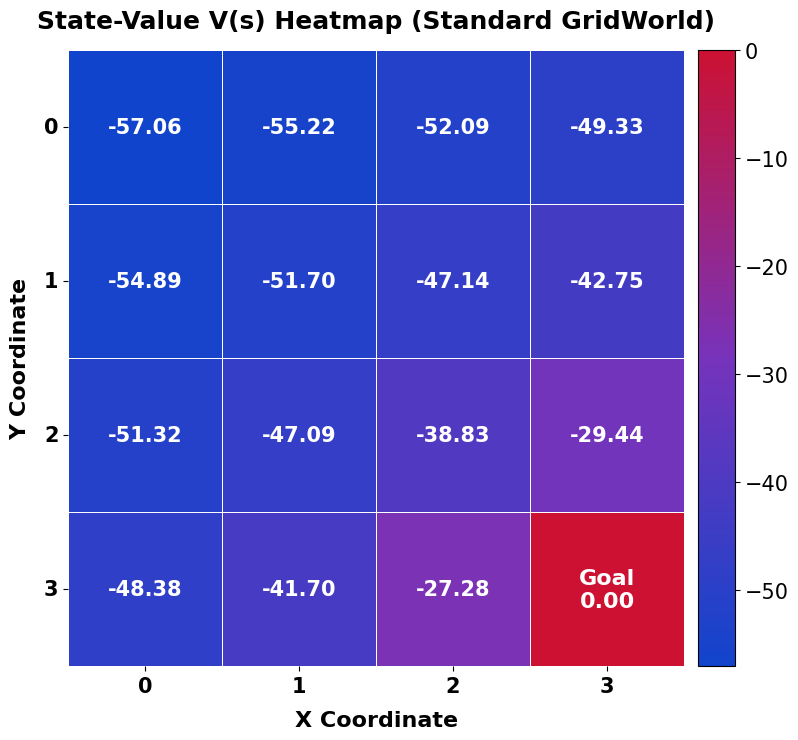

저장: Results/heatmap_standard.png


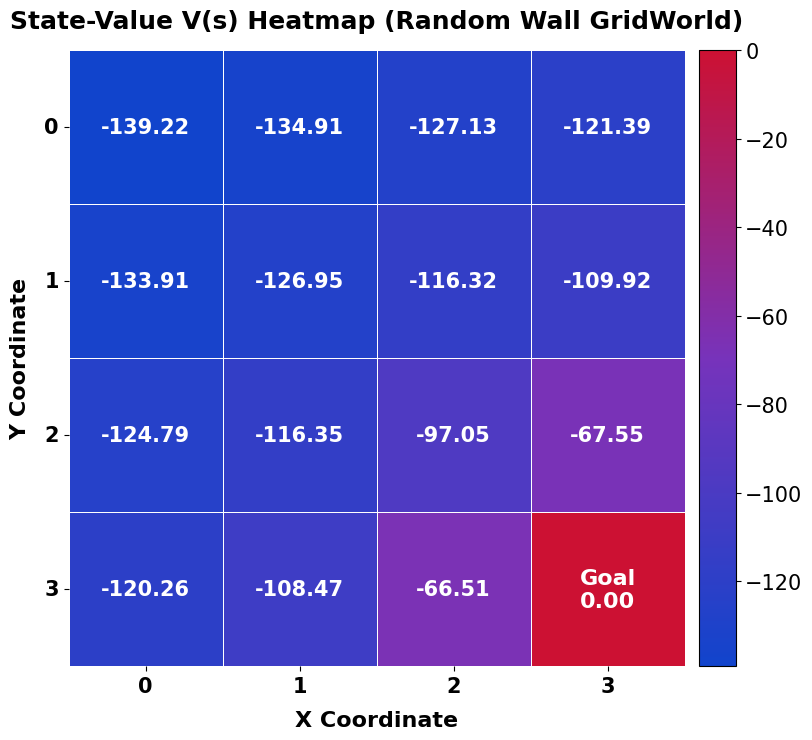

저장: Results/heatmap_random_wall.png


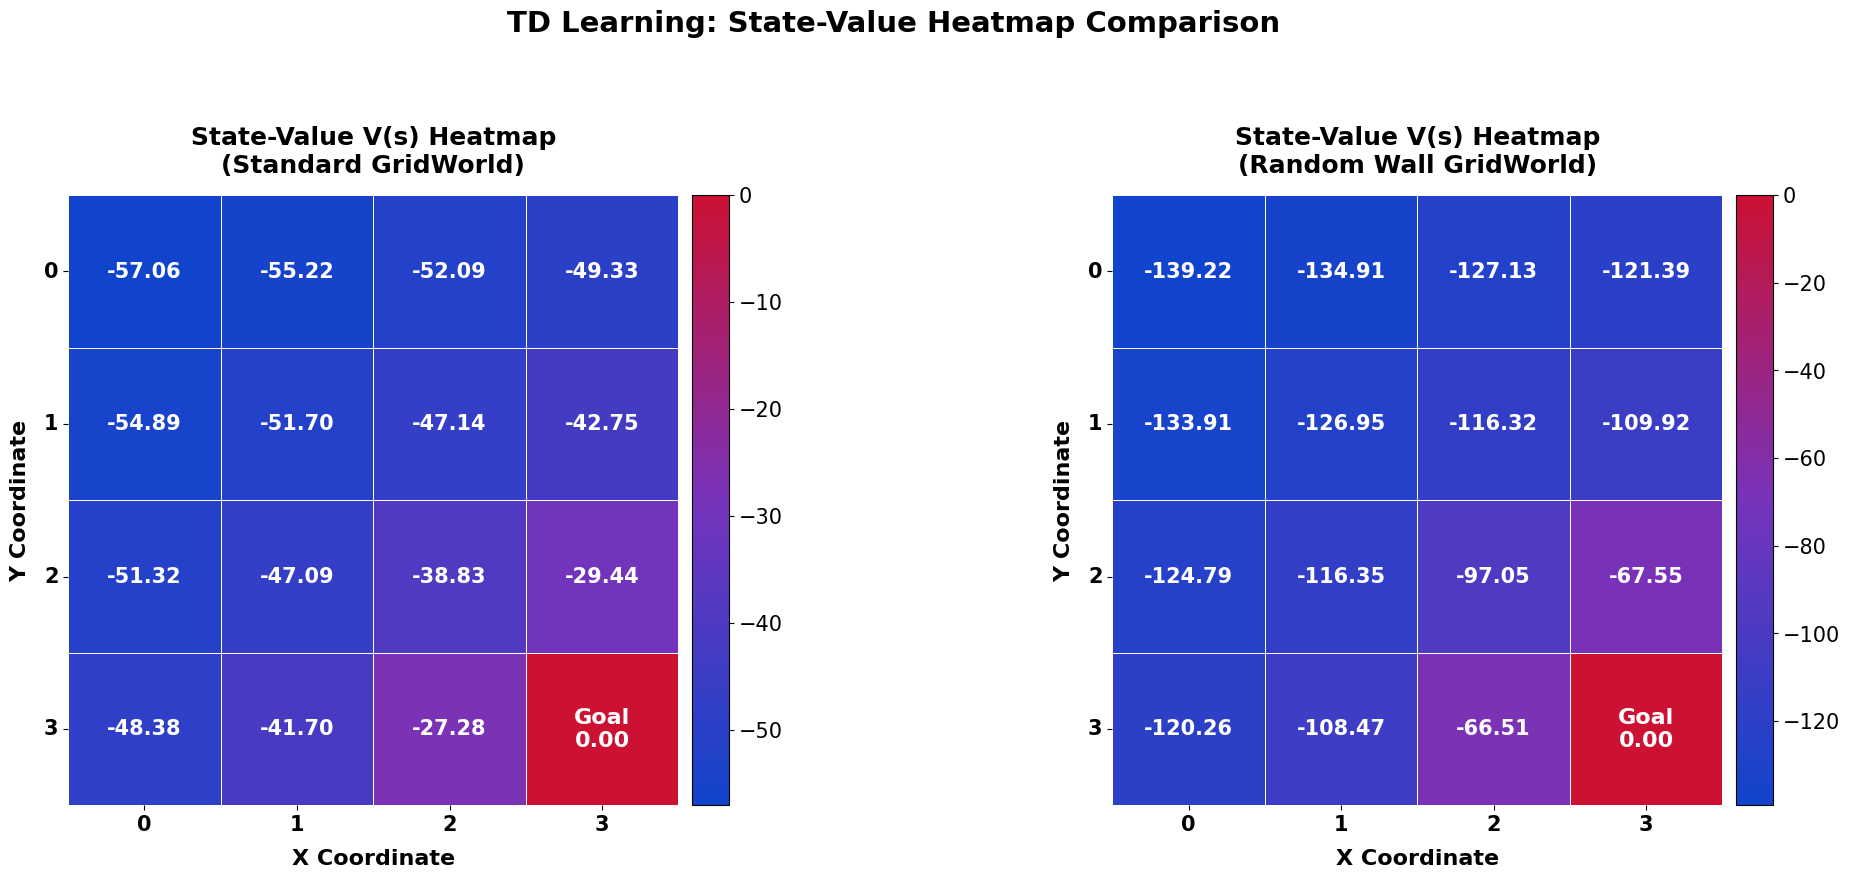

저장: Results/heatmap_comparison.png


In [26]:

# ============================================================
# [셀 3] 상태가치 V(s) 히트맵 시각화
#
# 컬러맵: 파랑(가장 부정적) → 붉은색(목표=0)
# 정사각형 4×4 격자 / colorbar 높이 = 히트맵 높이
# ============================================================

from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── 커스텀 컬러맵 (파랑 → 보라 → 빨강, 부드러운 전환) ──────
_CMAP_COLORS = ['#1144CC', '#7733BB', '#CC1133']
CUSTOM_CMAP  = LinearSegmentedColormap.from_list('br', _CMAP_COLORS, N=256)

# ── 공통 폰트 크기 ────────────────────────────────────────────
T_FS = 18    # 그래프 제목
L_FS = 16    # 축 레이블
K_FS = 15    # 축 눈금
C_FS = 15    # 셀 숫자
S_FS = 21    # 전체 제목 (suptitle)


def plot_value_heatmap(V, title, ax):
    """상태가치 V[x][y]를 정사각형 히트맵으로 시각화합니다."""
    data = np.array([[V[x][y] for x in range(4)] for y in range(4)],
                    dtype=float)
    vmin = data.min()

    # seaborn 히트맵 (colorbar는 별도 생성)
    sns.heatmap(
        data, ax=ax,
        cmap=CUSTOM_CMAP, vmin=vmin, vmax=0,
        annot=False,
        linewidths=0.7, linecolor='white',
        cbar=False,
    )

    # 정사각형 강제
    ax.set_aspect('equal')

    # colorbar: make_axes_locatable 로 히트맵 높이와 정확히 일치
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="6%", pad=0.14)
    sm  = plt.cm.ScalarMappable(
        cmap=CUSTOM_CMAP, norm=plt.Normalize(vmin=vmin, vmax=0)
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=K_FS)

    # 셀 텍스트 (배경 밝기 기반 글자색 자동 결정)
    for y_i in range(4):
        for x_i in range(4):
            val = data[y_i][x_i]
            if x_i == 3 and y_i == 3:
                ax.text(x_i + 0.5, y_i + 0.5,
                        f'Goal\n{val:.2f}',
                        ha='center', va='center',
                        fontsize=C_FS + 1, color='white', fontweight='bold')
            else:
                norm_val  = (val - vmin) / (-vmin) if vmin != 0 else 0
                r, g, b, _ = CUSTOM_CMAP(norm_val)
                luminance  = 0.299 * r + 0.587 * g + 0.114 * b
                txt_color  = 'white' if luminance < 0.50 else 'black'
                ax.text(x_i + 0.5, y_i + 0.5,
                        f'{val:.2f}',
                        ha='center', va='center',
                        fontsize=C_FS, color=txt_color, fontweight='bold')

    ax.set_title(title, fontsize=T_FS, fontweight='bold', pad=16)
    ax.set_xlabel('X Coordinate', fontsize=L_FS, fontweight='bold', labelpad=10)
    ax.set_ylabel('Y Coordinate', fontsize=L_FS, fontweight='bold', labelpad=10)
    ax.set_xticks(np.arange(4) + 0.5)
    ax.set_xticklabels(range(4), fontsize=K_FS, fontweight='bold')
    ax.set_yticks(np.arange(4) + 0.5)
    ax.set_yticklabels(range(4), fontsize=K_FS, fontweight='bold', rotation=0)


# ── 개별 히트맵 ─────────────────────────────────────────────
for V_tbl, title, fname in [
    (std_V_td,
     'State-Value V(s) Heatmap (Standard GridWorld)',
     'Results/heatmap_standard.png'),
    (rw_V_td,
     'State-Value V(s) Heatmap (Random Wall GridWorld)',
     'Results/heatmap_random_wall.png'),
]:
    fig, ax = plt.subplots(figsize=(9, 8))
    plot_value_heatmap(V_tbl, title, ax)
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"저장: {fname}")

# ── 나란히 비교 히트맵 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
plot_value_heatmap(std_V_td,
                   'State-Value V(s) Heatmap\n(Standard GridWorld)', axes[0])
plot_value_heatmap(rw_V_td,
                   'State-Value V(s) Heatmap\n(Random Wall GridWorld)', axes[1])
fig.suptitle('TD Learning: State-Value Heatmap Comparison',
             fontsize=S_FS, fontweight='bold', y=1.04)
plt.subplots_adjust(wspace=0.58)
plt.savefig('Results/heatmap_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("저장: Results/heatmap_comparison.png")


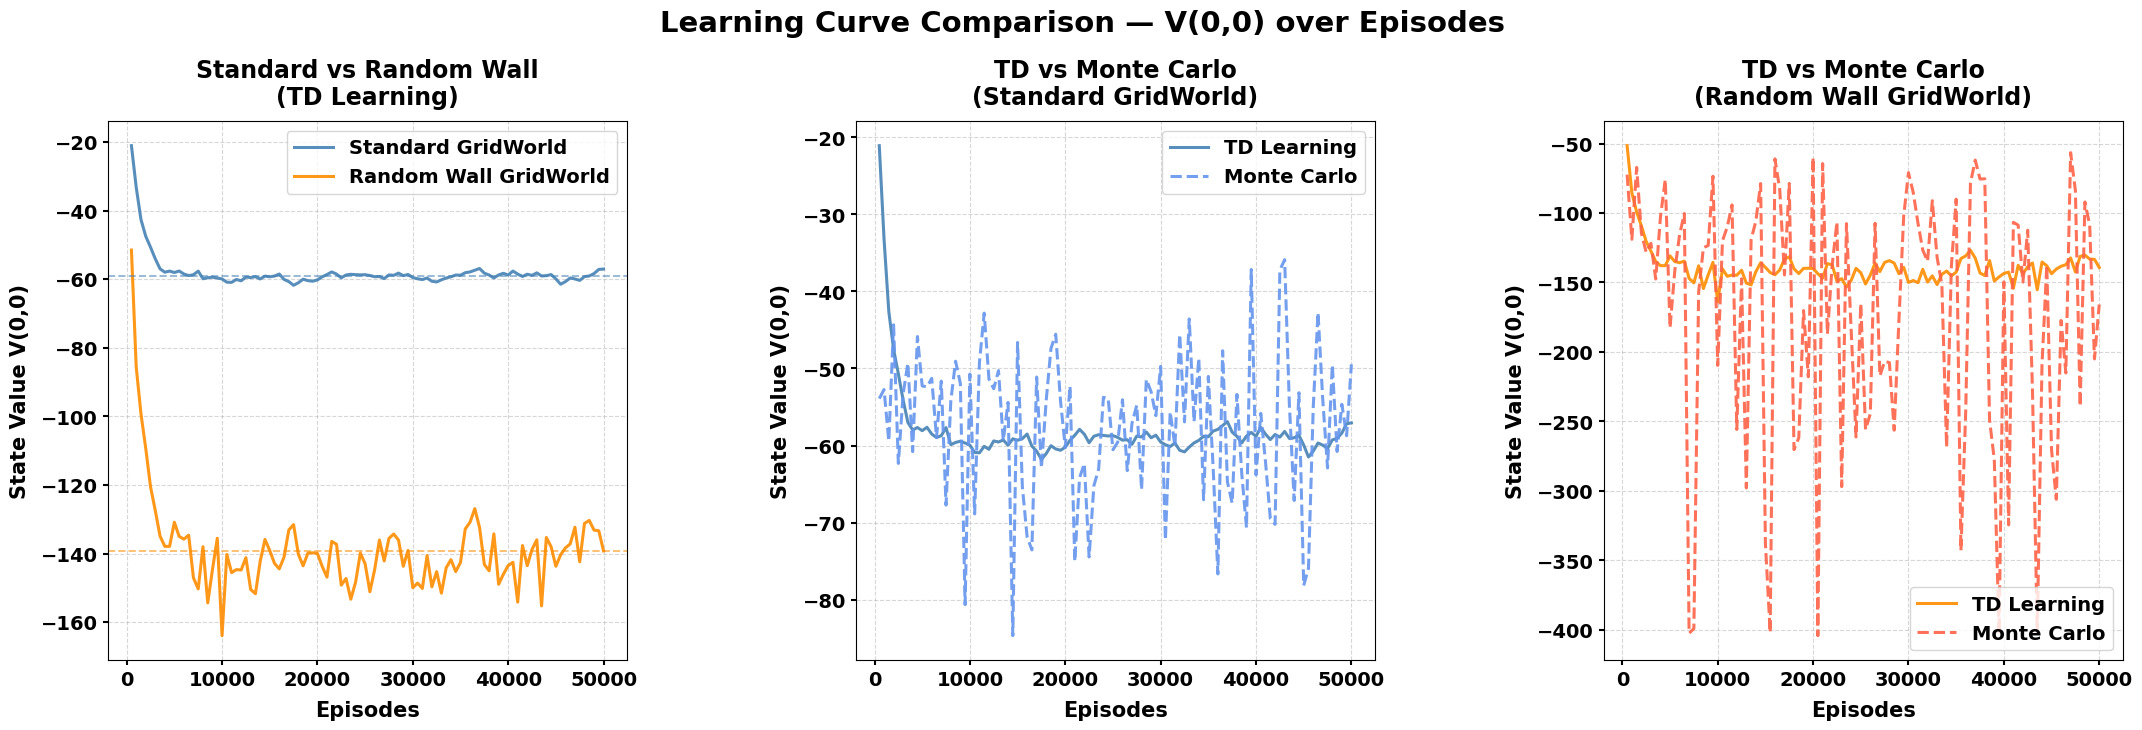

저장: Results/learning_curves.png


In [27]:

# ============================================================
# [셀 4] 학습 곡선(Learning Curves) 비교
#
#   그래프 ①: Standard vs Random Wall (TD)
#   그래프 ②: TD vs MC (Standard GridWorld)
#   그래프 ③: TD vs MC (Random Wall GridWorld)
# ============================================================

from matplotlib import font_manager

df  = pd.read_csv('Results/learning_history.csv')
eps = df['Episode'].values

# 폰트 크기
_T = 17    # 그래프 제목
_L = 15    # 축 레이블
_K = 14    # 축 눈금
_G = 14    # 범례
_S = 21    # 전체 제목

# 범례 굵게 설정용 FontProperties
_bold_fp = font_manager.FontProperties(weight='bold', size=_G)

fig, axes = plt.subplots(1, 3, figsize=(26, 7))
fig.suptitle('Learning Curve Comparison — V(0,0) over Episodes',
             fontsize=_S, fontweight='bold', y=1.04)
plt.subplots_adjust(wspace=0.44)

# ── ① Standard vs Random Wall (TD) ───────────────────────────
ax = axes[0]
ax.plot(eps, df['Standard_TD'],   color='steelblue', lw=2.2, alpha=0.9,
        label='Standard GridWorld')
ax.plot(eps, df['RandomWall_TD'], color='darkorange', lw=2.2, alpha=0.9,
        label='Random Wall GridWorld')
ax.axhline(y=df['Standard_TD'].iloc[-20:].mean(),
           color='steelblue',  ls='--', lw=1.4, alpha=0.55)
ax.axhline(y=df['RandomWall_TD'].iloc[-20:].mean(),
           color='darkorange', ls='--', lw=1.4, alpha=0.55)
ax.set_title('Standard vs Random Wall\n(TD Learning)',
             fontsize=_T, fontweight='bold', pad=12)
ax.set_xlabel('Episodes',           fontsize=_L, fontweight='bold', labelpad=8)
ax.set_ylabel('State Value V(0,0)', fontsize=_L, fontweight='bold', labelpad=8)
ax.tick_params(axis='both', labelsize=_K, width=1.5)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')
leg = ax.legend(prop=_bold_fp)
ax.grid(True, ls='--', alpha=0.5)

# ── ② TD vs MC (Standard GridWorld) ─────────────────────────
ax = axes[1]
ax.plot(eps, df['Standard_TD'], color='steelblue',      lw=2.2, alpha=0.9,
        label='TD Learning')
ax.plot(eps, df['Standard_MC'], color='cornflowerblue', lw=2.2, alpha=0.9,
        ls='--', label='Monte Carlo')
ax.set_title('TD vs Monte Carlo\n(Standard GridWorld)',
             fontsize=_T, fontweight='bold', pad=12)
ax.set_xlabel('Episodes',           fontsize=_L, fontweight='bold', labelpad=8)
ax.set_ylabel('State Value V(0,0)', fontsize=_L, fontweight='bold', labelpad=8)
ax.tick_params(axis='both', labelsize=_K, width=1.5)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')
ax.legend(prop=_bold_fp)
ax.grid(True, ls='--', alpha=0.5)

# ── ③ TD vs MC (Random Wall GridWorld) ──────────────────────
ax = axes[2]
ax.plot(eps, df['RandomWall_TD'], color='darkorange', lw=2.2, alpha=0.9,
        label='TD Learning')
ax.plot(eps, df['RandomWall_MC'], color='tomato',     lw=2.2, alpha=0.9,
        ls='--', label='Monte Carlo')
ax.set_title('TD vs Monte Carlo\n(Random Wall GridWorld)',
             fontsize=_T, fontweight='bold', pad=12)
ax.set_xlabel('Episodes',           fontsize=_L, fontweight='bold', labelpad=8)
ax.set_ylabel('State Value V(0,0)', fontsize=_L, fontweight='bold', labelpad=8)
ax.tick_params(axis='both', labelsize=_K, width=1.5)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')
ax.legend(prop=_bold_fp)
ax.grid(True, ls='--', alpha=0.5)

plt.savefig('Results/learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print("저장: Results/learning_curves.png")


In [28]:

# ============================================================
# [셀 5] 결과 분석 — Standard vs Random Wall GridWorld 비교
# ============================================================

print("=" * 68)
print("결과 분석: Standard GridWorld vs Random Wall GridWorld (TD Learning)")
print("=" * 68)

# ── 최종 V(s) 테이블 출력 ───────────────────────────────────
for label, V_tbl in [("■ Standard   GridWorld", std_V_td),
                     ("■ RandomWall GridWorld", rw_V_td)]:
    print(f"\n{label} — 최종 V(s) 테이블")
    print("         X=0      X=1      X=2      X=3")
    for y in range(4):
        row = "  ".join(f"{V_tbl[x][y]:7.2f}" for x in range(4))
        print(f"  Y={y}   {row}")

# ── 주요 상태 수치 비교표 ─────────────────────────────────────
print(f"\n{'상태':<24} {'Standard TD':>12}  {'RandomWall TD':>14}  {'차이':>8}")
print("-" * 64)
key_states = [
    ("V(0,0)  — 시작점",     0, 0),
    ("V(3,0)  — 우상단",     3, 0),
    ("V(0,3)  — 좌하단",     0, 3),
    ("V(2,2)  — 목표 근처",  2, 2),
    ("V(3,3)  — 목표점",     3, 3),
]
for label, x, y in key_states:
    v_std = std_V_td[x][y]
    v_rw  = rw_V_td[x][y]
    diff  = v_rw - v_std
    print(f"{label:<24} {v_std:>12.2f}  {v_rw:>14.2f}  {diff:>8.2f}")

ratio = (rw_V_td[0][0] / std_V_td[0][0]) if std_V_td[0][0] != 0 else float('inf')

print(f"""
■ 핵심 분석 (무작위 벽 V(0,0) ÷ 표준 V(0,0) ≈ {ratio:.2f}배 더 큰 음수)

  1. 불필요한 스텝 누적
     벽 방향으로 이동 시도 → 위치 그대로지만 −1 보상이 계속 누적
     → 유효 이동 없이 페널티만 쌓임

  2. 최단 경로 차단
     랜덤 벽이 지름길을 막으면 에이전트는 무작위로 우회로를 탐색
     → 더 많은 스텝 소모 → 더 낮은 상태 가치

  3. 갇힘(Trapped) 현상
     드물지만 주변이 벽으로 둘러싸여 장기간 이탈 불가한 에피소드 발생
     → 매우 큰 음수 보상 → 평균 가치를 크게 끌어내림

  4. TD vs Monte Carlo
     TD는 에피소드 종료 전에도 부분적으로 업데이트 가능
     → 특히 무작위 벽 환경처럼 에피소드가 길어질 때 MC보다 빠르게 수렴
""")


결과 분석: Standard GridWorld vs Random Wall GridWorld (TD Learning)

■ Standard   GridWorld — 최종 V(s) 테이블
         X=0      X=1      X=2      X=3
  Y=0    -57.06   -55.22   -52.09   -49.33
  Y=1    -54.89   -51.70   -47.14   -42.75
  Y=2    -51.32   -47.09   -38.83   -29.44
  Y=3    -48.38   -41.70   -27.28     0.00

■ RandomWall GridWorld — 최종 V(s) 테이블
         X=0      X=1      X=2      X=3
  Y=0   -139.22  -134.91  -127.13  -121.39
  Y=1   -133.91  -126.95  -116.32  -109.92
  Y=2   -124.79  -116.35   -97.05   -67.55
  Y=3   -120.26  -108.47   -66.51     0.00

상태                        Standard TD   RandomWall TD        차이
----------------------------------------------------------------
V(0,0)  — 시작점                  -57.06         -139.22    -82.16
V(3,0)  — 우상단                  -49.33         -121.39    -72.05
V(0,3)  — 좌하단                  -48.38         -120.26    -71.88
V(2,2)  — 목표 근처                -38.83          -97.05    -58.22
V(3,3)  — 목표점                    0.00            